## Imported Libraries

The following libraries are imported to support data processing, numerical computation, and visualization tasks:

- **`ast`**  
  Enables interaction with Python’s Abstract Syntax Tree (AST), allowing programmatic inspection, analysis, and transformation of Python source code.

- **`pandas (pd)`**  
  Provides high-level data structures and functions for efficient data manipulation, cleaning, and analysis, particularly for tabular datasets.

- **`seaborn (sns)`**  
  A statistical data visualization library built on top of Matplotlib, offering concise syntax and aesthetically enhanced plots.

- **`matplotlib.pyplot (plt)`**  
  A foundational plotting library used to create static, animated, and interactive visualizations.

- **`numpy (np)`**  
  Supports numerical computing through efficient multi-dimensional arrays and a comprehensive set of mathematical functions.


In [2]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

## Data Loading

The dataset is loaded into a Pandas DataFrame using the `read_csv` function:

- **`pd.read_csv()`**  
  Reads a CSV (Comma-Separated Values) file from the specified file path and converts it into a Pandas DataFrame.

- **File Path**  
  The file path points to a local dataset containing supply chain shipment pricing data.

- **`df`**  
  The resulting DataFrame stores the loaded dataset and serves as the primary structure for subsequent data exploration, cleaning, and analysis.

This step initializes the dataset for further analytical and visualization tasks.


In [3]:
df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')
df

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",False,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,False,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,False,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,True,1392,Freight Included in Commodity Cost,134.03


## Dataset Structure Inspection

The `df.info()` method is used to examine the structure of the dataset, including:

- The total number of records and columns
- Column names
- Non-null value counts
- Data types
- Memory usage

This step helps identify missing values, inappropriate data types, and columns requiring preprocessing.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

## Column Selection

A subset of relevant columns is selected to focus the analysis on shipment, vendor, and cost-related attributes.  
Reducing the number of columns improves clarity, performance, and analytical relevance.

The selected columns include:
- Geographic and vendor information
- Shipment and product classification details
- Key shipment dates
- Cost and insurance values

The filtered dataset is reassigned to the DataFrame for further processing.


In [5]:
cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]

df = df[cols_to_keep]


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    10324 non-null  object 
 1   vendor                     10324 non-null  object 
 2   shipment mode              9964 non-null   object 
 3   product group              10324 non-null  object 
 4   sub classification         10324 non-null  object 
 5   po sent to vendor date     10324 non-null  object 
 6   scheduled delivery date    10324 non-null  object 
 7   delivered to client date   10324 non-null  object 
 8   freight cost (usd)         10324 non-null  object 
 9   line item insurance (usd)  10037 non-null  float64
dtypes: float64(1), object(9)
memory usage: 806.7+ KB


## Date Type Conversion

Certain date-related columns were initially stored as object (string) types.  
These columns are explicitly converted to datetime format using `pd.to_datetime()` to enable accurate date-based calculations and comparisons.

Converted columns:
- `scheduled delivery date`
- `delivered to client date`

This conversion ensures consistency and allows for time-series analysis, delay calculations, and proper sorting.


In [7]:
list_to_date = ['scheduled delivery date', 'delivered to client date']

for i in list_to_date:
    df[i] = pd.to_datetime(df[i])

C:\Users\HP\AppData\Local\Temp\ipykernel_3100\2255871080.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_3100\2255871080.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_3100\2255871080.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_3100\2255871080.py

## Post-Processing Validation

After column selection and data type conversion, `df.info()` is executed again to validate:

- Successful reduction of columns
- Correct datetime data types
- Updated memory usage

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    10324 non-null  object        
 1   vendor                     10324 non-null  object        
 2   shipment mode              9964 non-null   object        
 3   product group              10324 non-null  object        
 4   sub classification         10324 non-null  object        
 5   po sent to vendor date     10324 non-null  object        
 6   scheduled delivery date    10324 non-null  datetime64[ns]
 7   delivered to client date   10324 non-null  datetime64[ns]
 8   freight cost (usd)         10324 non-null  object        
 9   line item insurance (usd)  10037 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 806.7+ KB


# To what extent do shipment delays occur?

### Methodology

- To evaluate shipment delivery performance, the dataset was first cleaned and relevant variables were selected. Scheduled and actual delivery date fields were converted to datetime format to enable accurate date-based calculations.

- Delivery delay was calculated as the difference, in days, between the scheduled delivery date and the actual delivery date. Based on this calculated delay, shipments were classified into three categories: early, on time, and late.

- Frequency analysis was conducted to determine the distribution of delivery delays and delivery status. Visualizations, including bar charts and pie charts, were used to illustrate delay distributions and the proportion of shipments by delivery status.

This methodology provides both quantitative and visual insights into shipment timeliness and overall delivery performance.


## Delivery Delay Calculation

A copy of the cleaned dataset is created to preserve the original DataFrame and allow independent analysis of delivery delays.

```python
df_delai = df.copy()


In [9]:
df_delai = df.copy()

In [10]:
df_delai['delay'] = (
    df['scheduled delivery date'] - df['delivered to client date']
    ).dt.days
df_delai



,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36


## Delay Frequency Distribution

The frequency of shipment delays is analyzed using the `value_counts()` method applied to the `delay` column.

The resulting output shows the number of occurrences for each unique delay value, limited to the most frequent observations for clarity.

This step helps identify dominant delivery patterns, such as the prevalence of on-time deliveries and commonly occurring early or late delivery durations.


In [11]:
df_delai_count = df_delai.value_counts('delay').head(19).to_frame()
df_delai_count

,count
delay,
0,6324
17,127
6,119
8,112
13,107
7,106
2,93
-1,92
19,85


## Visualization of Shipment Delay Distribution

A bar chart is used to visualize the distribution of shipment delays based on their frequency.

The Seaborn visualization style is configured to use a clean, publication-friendly theme with axis ticks enabled. A bar plot is then generated using the delay values on the x-axis and the corresponding number of shipments on the y-axis.

Color encoding is applied based on shipment count to enhance visual differentiation between frequently and infrequently occurring delay values. Non-essential plot borders are removed to improve readability.

Axis labels and a descriptive title are added to clearly communicate the meaning of the visualization. The y-axis is constrained to focus on the relevant range of shipment counts, and layout adjustments are applied to prevent label overlap.

This visualization provides a clear overview of delivery performance, highlighting the most common delay durations and the overall distribution of shipment timeliness.


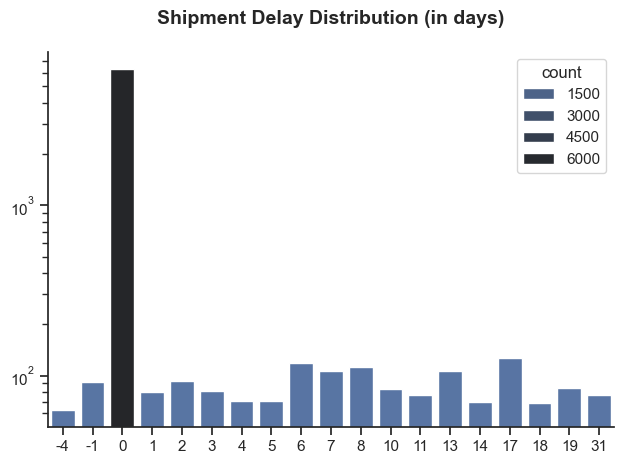

In [12]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_delai_count,
            x = 'delay',
            y = 'count',           
            hue = 'count',
            palette = 'dark:b_r',
           )
sns.despine()                                        # Remove the top and right spines from plot


plt.yscale("log")
plt.xlabel('')
plt.ylabel('')
plt.title('Shipment Delay Distribution (in days)', pad = 20, fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### insight: 
-------------------------------------------------------------
The shipment delay distribution is heavily concentrated around 0–2 days, indicating that the majority of shipments are delivered on time or with minimal delay. However, the distribution shows a long right tail, with a smaller but notable number of shipments experiencing extended delays of up to 30+ days. This suggests that while overall operational performance is stable, exceptional cases—likely driven by supply chain disruptions, customs clearance, or carrier issues—have a disproportionate impact and represent a key opportunity for targeted process improvement.

---------------------------------------------------------------------------------------------------------------------------------------------------------------

## Shipment Delivery Status Classification

A new categorical variable, `shipment delivery`, is created to classify each shipment based on its delivery performance relative to the scheduled delivery date.

The classification logic is defined as follows:
- Shipments delivered **before** the scheduled date are labeled as **early**.
- Shipments delivered **on** the scheduled date are labeled as **on time**.
- Shipments delivered **after** the scheduled date are labeled as **late**.

This categorization is implemented using conditional logic to efficiently assign delivery status across all records.

The resulting variable enables grouped analysis and comparison of shipment performance across vendors, countries, and shipment modes.


In [13]:
df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)

df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


## Shipment Delivery Status Distribution

A pie chart is used to visualize the proportion of shipments by delivery status, categorized as early, on time, or late.

The chart is generated by computing the frequency of each delivery status and displaying their relative contributions as percentages of the total number of shipments. Percentage labels are included to provide precise quantitative insight into each category.

The visualization offers an intuitive overview of overall delivery performance, clearly illustrating the balance between on-time, early, and delayed shipments. This representation supports high-level assessment of operational efficiency and service reliability.


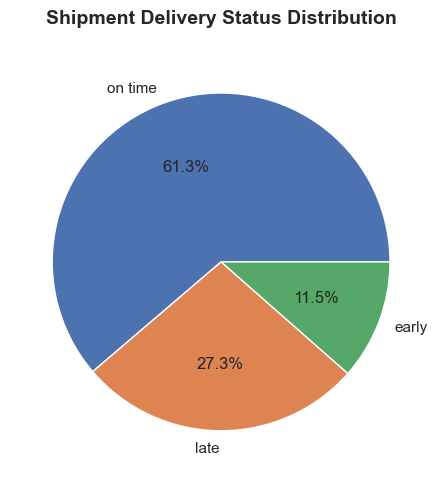

In [14]:
df_delai['shipment delivery'].value_counts().plot(kind = 'pie',
                xlabel = '', 
                ylabel = '',
                figsize = (8,5),
                autopct = '%1.1f%%',                # Show percentages on pie chart
                
                  )

plt.title('Shipment Delivery Status Distribution', pad = 20, fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

### insight:
-------------------------------------------------------------
The majority of shipments (61.3%) are delivered on time, reflecting generally reliable delivery performance. However, a meaningful proportion of shipments (27.3%) arrive late, indicating persistent fulfillment or logistics challenges that could impact customer satisfaction. Early deliveries account for a smaller share (11.5%), suggesting limited buffer or proactive acceleration in the delivery process. Overall, while on-time performance is strong, reducing late deliveries represents the most significant opportunity for operational improvement.

-------------------------------------------------------------

In [16]:
df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [45]:
df_mode = df_delai.pivot_table(index= 'shipment mode',
                     columns= 'shipment delivery',
                     aggfunc= 'size',
                     )

df_mode

shipment delivery,early,late,on time
shipment mode,,,
Air,587,1183,4343
Air Charter,75,452,123
Ocean,65,15,291
Truck,455,1137,1238


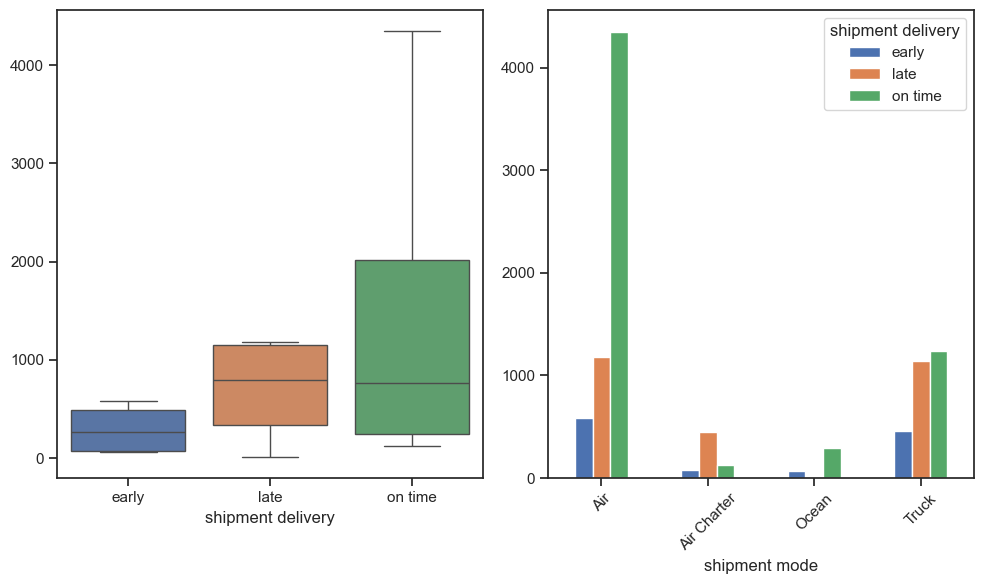

In [67]:
fig , ax = plt.subplots(1, 2, figsize =(10,6))

df_mode.plot(kind = 'bar' ,
             ax = ax[1]
             )
ax[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_mode,
            ax = ax[0])

fig.tight_layout()